In [1]:
import numpy as np, pandas as pd
import warnings
warnings.filterwarnings('ignore')

data = pd.read_excel('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Sample/Sample.xlsx')
data.replace({'diagnosis': {'M':1, 'B':0}}, inplace=True)
data.head(11)

,diagnosis,radius_mean,radius_se,radius_worst
0,1,17.99,1.0950,25.38
1,1,20.57,0.5435,24.99
2,1,19.69,0.7456,23.57
3,1,11.42,0.4956,14.91
4,1,20.29,0.7572,22.54
5,1,12.45,0.3345,15.47
6,1,18.25,0.4467,22.88
7,1,13.71,0.5835,17.06
8,1,13.00,0.3063,15.49
9,1,12.46,0.2976,15.09


In [2]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

Data shape: (10, 4)
Columns: ['diagnosis', 'radius_mean', 'radius_se', 'radius_worst']


In [3]:
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

models = {
    'CTGAN': CTGANSynthesizer,
    'CopulaGAN': CopulaGANSynthesizer,
    'TVAE': TVAESynthesizer,
    'GaussianCopula': GaussianCopulaSynthesizer
}

synthetic_data = {}
diagnostics = {}
quality_report = {}

for name, Synthesizer in models.items():
    print(f"\nSynthesizing with {name}...")

    model = Synthesizer(metadata)
    model.fit(data)

    synthetic_data[name] = model.sample(10)

    diagnostics[name] = run_diagnostic(data, synthetic_data[name], metadata)
    quality_report[name] = evaluate_quality(data, synthetic_data[name], metadata)

    print(f'{name} synthetic data generated successfully!')

print("=========================================")
for name in models:
    print(f"Diagnostics for {name}:")
    print(diagnostics[name])
    print("-" * 40)

print("=========================================")
for name in models:
    print(f"Quality report for {name}:")
    print(quality_report[name])
    print("-" * 40)


Synthesizing with CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 4/4 [00:00<00:00, 559.39it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 283.34it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 438.12it/s]|
Column Shapes Score: 70.0%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 157.22it/s]|
Column Pair Trends Score: 67.13%

Overall Score (Average): 68.56%

CTGAN synthetic data generated successfully!

Synthesizing with CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 4/4 [00:00<00:00, 777.12it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 500.33it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00

In [4]:
from IPython.display import display

print("=========================================")
print("Synthetic data samples:")
for name in models:
    print(f"\nSynthetic data from {name}:")
    display(synthetic_data[name]) 
    print("-" * 40)

Synthetic data samples:

Synthetic data from CTGAN:


,diagnosis,radius_mean,radius_se,radius_worst
0,1,20.42,0.7722,19.90
1,1,17.55,0.4861,24.34
2,1,14.49,0.6498,18.44
3,1,12.06,0.5151,14.91
4,1,14.55,0.6292,17.45
5,1,17.48,0.8620,19.80
6,1,20.57,0.9972,20.94
7,1,20.57,0.4790,17.79
8,1,14.05,0.6386,20.24
9,1,16.71,0.9542,25.38


----------------------------------------

Synthetic data from CopulaGAN:


,diagnosis,radius_mean,radius_se,radius_worst
0,1,15.01,1.0950,22.11
1,1,20.27,0.8267,25.38
2,1,20.57,1.0950,16.47
3,1,13.28,0.3652,20.43
4,1,17.81,1.0950,23.13
5,1,19.18,1.0340,20.51
6,1,20.57,0.4009,25.38
7,1,20.57,0.9136,25.38
8,1,15.11,0.4354,24.47
9,1,17.42,0.9759,24.99


----------------------------------------

Synthetic data from TVAE:


,diagnosis,radius_mean,radius_se,radius_worst
0,1,16.22,0.5922,24.23
1,1,17.58,0.9400,19.58
2,1,16.32,0.4034,25.11
3,1,17.98,0.6479,23.81
4,1,16.48,0.7133,16.67
5,1,16.41,0.5203,18.92
6,1,14.65,0.3555,20.36
7,1,15.31,0.4328,18.96
8,1,17.77,0.5761,19.74
9,1,15.04,0.3498,15.72


----------------------------------------

Synthetic data from GaussianCopula:


,diagnosis,radius_mean,radius_se,radius_worst
0,1,12.13,0.3732,14.91
1,1,12.44,0.3437,15.23
2,1,15.45,0.7085,25.38
3,1,13.30,0.3394,15.45
4,1,14.55,0.4320,14.92
5,1,17.74,0.3788,25.38
6,1,11.42,0.2986,14.91
7,1,16.27,0.4056,21.50
8,1,11.84,0.6288,14.91
9,1,18.49,0.8387,17.04


----------------------------------------


In [5]:
from numpy.linalg import norm

real_data = data.drop(columns=['diagnosis'])
synthetic_data = synthetic_data['GaussianCopula'].drop(columns=['diagnosis'])

# ---------- Compute 10×10 Cosine Similarity ----------
def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

R = normalize_rows(real_data.to_numpy(float))
S = normalize_rows(synthetic_data.to_numpy(float))

cosine_matrix = R @ S.T   # 10 × 10 matrix

# Print in a readable format
cosine_df = pd.DataFrame(cosine_matrix,
                         index=[f"R{i+1}" for i in range(10)],
                         columns=[f"S{j+1}" for j in range(10)])

print(cosine_df)

           S1        S2        S3        S4        S5        S6        S7  \
R1   0.997679  0.997515  0.997503  0.995405  0.987728  0.999715  0.999130   
R2   0.999980  0.999993  0.989934  0.999757  0.996454  0.996899  0.999385   
R3   0.999904  0.999916  0.988908  0.999861  0.997040  0.996241  0.999070   
R4   0.999546  0.999471  0.994304  0.998322  0.992889  0.998951  0.999945   
R5   0.998737  0.998820  0.982745  0.999720  0.999194  0.992382  0.996818   
R6   0.999983  0.999973  0.991434  0.999452  0.995467  0.997705  0.999711   
R7   0.999945  0.999930  0.991979  0.999298  0.995036  0.997995  0.999806   
R8   0.999956  0.999926  0.991547  0.999379  0.995391  0.997659  0.999670   
R9   0.999874  0.999909  0.988529  0.999920  0.997202  0.996111  0.999005   
R10  0.999965  0.999983  0.989703  0.999788  0.996575  0.996783  0.999330   

           S8        S9       S10  
R1   0.999312  0.998514  0.978146  
R2   0.999163  0.999714  0.990431  
R3   0.998799  0.999654  0.991497  
R4   0.9

In [9]:
# ---------- Find best synthetic match ----------

def best_matches(cos_matrix):
    best_idx = np.argmax(cos_matrix, axis=1)
    best_sim = cos_matrix[np.arange(len(cos_matrix)), best_idx]
    return best_idx, best_sim

best_idx, best_sim = best_matches(cosine_matrix)
print(f"Best matches: {best_idx}, with similarity: {best_sim}")

Best matches: [5 1 1 6 3 0 0 8 3 1], with similarity: [0.99971495 0.99999263 0.99991599 0.99994504 0.99972004 0.99998267
 0.99994486 0.99996285 0.99992034 0.99998329]


In [11]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

# real_df and synth_df should already be pandas DataFrames
# with columns: "radius_mean", "radius_se", "radius_worst"


# row normalization 
def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

# Cosine similarity & association 
def associate_real_with_synthetic(real_data: pd.DataFrame,
                                  synthetic_data: pd.DataFrame):
  
    num_cols = ["radius_mean", "radius_se", "radius_worst"]

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    # Normalize rows
    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    # Cosine similarity matrix (N_real x N_synth)
    cos_sim = R_norm @ S_norm.T
   
    best_s_idx = np.argmax(cos_sim, axis=1)      
    best_sim   = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

# Call with DataFrames, not R, S
best_indices, best_sims, cos_matrix = associate_real_with_synthetic(real_data, synthetic_data)

print("Real → Synthetic associations (using cosine similarity):\n")
for i in range(len(real_data)):  
    r_name = f"R{i+1}"
    s_name = f"S{best_indices[i] + 1}"   
    sim_val = best_sims[i]
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim_val:.4f}")

Real → Synthetic associations (using cosine similarity):

R1  →  S6   cosine similarity = 0.9997
R2  →  S2   cosine similarity = 1.0000
R3  →  S2   cosine similarity = 0.9999
R4  →  S7   cosine similarity = 0.9999
R5  →  S4   cosine similarity = 0.9997
R6  →  S1   cosine similarity = 1.0000
R7  →  S1   cosine similarity = 0.9999
R8  →  S9   cosine similarity = 1.0000
R9  →  S4   cosine similarity = 0.9999
R10  →  S2   cosine similarity = 1.0000


In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

# row normalization
def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def associate_real_with_synthetic_unique(real_df: pd.DataFrame,
                                         synth_df: pd.DataFrame):
    """
    For each real sample, assign a unique synthetic sample:
    - use cosine similarity
    - if the best synthetic is already taken, use the next-best one.

    Returns
    -------
    assigned_synth : np.ndarray
        Index of the synthetic assigned to each real (shape: N_real, values in 0..M-1).
    assigned_sim   : np.ndarray
        Cosine similarity for that assignment (shape: N_real).
    cos_sim        : np.ndarray
        Full cosine similarity matrix (N_real x N_synth).
    """
    num_cols = ["radius_mean", "radius_se", "radius_worst"]

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    # Normalize rows
    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    # Cosine similarity matrix (N_real x N_synth)
    cos_sim = R_norm @ S_norm.T

    n_real, n_synth = cos_sim.shape

    # For each real sample, get synthetic indices sorted by similarity (descending)
    sorted_synth_indices = np.argsort(-cos_sim, axis=1)  # negative for descending

    # Order reals by how strong their best match is (strongest first)
    best_per_real = cos_sim.max(axis=1)
    real_order = np.argsort(-best_per_real)  # indices of reals, strongest first

    assigned_synth = -np.ones(n_real, dtype=int)   # -1 = not yet assigned
    assigned_sim = np.zeros(n_real, dtype=float)
    used_synth = set()

    # Greedy assignment: strongest reals choose first
    for i in real_order:
        for j in sorted_synth_indices[i]:
            if j not in used_synth:
                assigned_synth[i] = j
                assigned_sim[i] = cos_sim[i, j]
                used_synth.add(j)
                break
        # if we cannot find any unused synthetic, assigned_synth[i] stays -1

    return assigned_synth, assigned_sim, cos_sim


# ----- Use it -----
real_df = real_data          
synth_df = synthetic_data  

best_indices, best_sims, cos_matrix = associate_real_with_synthetic_unique(real_df, synth_df)

print("Real → Synthetic associations (unique, using cosine similarity):\n")
for i in range(len(real_df)):
    r_name = f"R{i+1}"
    if best_indices[i] == -1:
        print(f"{r_name}  →  (no available synthetic left)")
    else:
        s_name = f"S{best_indices[i] + 1}"   # +1 for human-friendly index
        sim_val = best_sims[i]
        print(f"{r_name}  →  {s_name}   cosine similarity = {sim_val:.4f}")

print("\nActual value for R1:")
if best_indices[0] == -1:
    print("R1 could not be assigned a unique synthetic.")
else:
    print(f"R1 is associated with S{best_indices[0] + 1} "
          f"with cosine similarity {best_sims[0]:.4f}")

Real → Synthetic associations (unique, using cosine similarity):

R1  →  S3   cosine similarity = 0.9975
R2  →  S2   cosine similarity = 1.0000
R3  →  S6   cosine similarity = 0.9962
R4  →  S8   cosine similarity = 0.9999
R5  →  S10   cosine similarity = 0.9956
R6  →  S9   cosine similarity = 0.9998
R7  →  S4   cosine similarity = 0.9993
R8  →  S7   cosine similarity = 0.9997
R9  →  S5   cosine similarity = 0.9972
R10  →  S1   cosine similarity = 1.0000

Actual value for R1:
R1 is associated with S3 with cosine similarity 0.9975


In [ ]:
import re
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment  # Hungarian algorithm


# ---------- 1. Row normalization for cosine similarity ----------
def normalize_rows(X: np.ndarray) -> np.ndarray:
    """
    Normalize each row vector in X to unit L2 norm.
    """
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms


# ---------- 2. Build cosine similarity matrix ----------
def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    """
    Compute cosine similarity matrix between real and synthetic samples.
    Returns an (N_real x N_synth) matrix.
    """
    if num_cols is None:
        # Default: use all numeric columns
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T   # shape: (N_real, N_synth)
    return cos_sim


# ---------- 3. Hungarian-based optimal matching ----------
def hungarian_match(real_df: pd.DataFrame,
                    synth_df: pd.DataFrame,
                    num_cols=None):
    """
    Perform optimal 1-to-1 matching between real and synthetic samples
    using the Hungarian algorithm on (1 - cosine_similarity) as cost.

    Returns
    -------
    row_ind : np.ndarray
        Indices of real samples in the matching (0-based).
    col_ind : np.ndarray
        Indices of synthetic samples matched to each real (0-based).
    selected_similarities : np.ndarray
        Cosine similarity values for each matched pair.
    avg_similarity : float
        Average cosine similarity over the matched pairs.
    cos_sim : np.ndarray
        Full cosine similarity matrix (N_real x N_synth).
    """
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # We want to maximize similarity → minimize cost = 1 - similarity
    # SciPy's linear_sum_assignment finds min-cost assignment.
    if n_real <= n_synth:
        # Each real gets a unique synthetic
        cost_matrix = 1.0 - cos_sim  # shape: (n_real, n_synth)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    else:
        # More reals than synthetics: assign each synthetic to at most one real.
        # Solve on the transposed matrix and flip indices back.
        cost_matrix = 1.0 - cos_sim.T  # shape: (n_synth, n_real)
        col_ind, row_ind = linear_sum_assignment(cost_matrix)
        # Now row_ind/col_ind are aligned so that:
        #   real index = row_ind[k], synthetic index = col_ind[k]
        selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())

    return row_ind, col_ind, selected_similarities, avg_similarity, cos_sim


# ---------- 4. Example usage with your variables ----------
# Replace `sample` and `synthetic_data` with your actual DataFrames
real_df = real_data
synth_df = synthetic_data

num_cols = ["radius_mean", "radius_se", "radius_worst"]

row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
    real_df, synth_df, num_cols=num_cols
)

# ---------- 5. Print the optimal 1-to-1 matches ----------
print("Optimal Real → Synthetic assignments (Hungarian, using cosine similarity):\n")
for r_idx, s_idx, sim in zip(row_ind, col_ind, sims):
    r_name = f"R{r_idx + 1}"   # +1 for human-friendly
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim:.4f}")

print(f"\nAverage cosine similarity over matched pairs: {avg_sim:.4f}")

# Example: R1's assigned synthetic (if R1 is in the matched set)
if 0 in row_ind:
    pos = np.where(row_ind == 0)[0][0]
    s_for_r1 = col_ind[pos]
    sim_r1 = sims[pos]
    print(f"\nR1 is matched to S{s_for_r1 + 1} with cosine similarity {sim_r1:.4f}")
else:
    print("\nR1 is not in the matched set (case where |R| > |S|).")


Optimal Real → Synthetic assignments (Hungarian, using cosine similarity):

R1  →  S3   cosine similarity = 0.9975
R2  →  S1   cosine similarity = 1.0000
R3  →  S4   cosine similarity = 0.9999
R4  →  S6   cosine similarity = 0.9990
R5  →  S10   cosine similarity = 0.9956
R6  →  S7   cosine similarity = 0.9997
R7  →  S8   cosine similarity = 0.9997
R8  →  S9   cosine similarity = 1.0000
R9  →  S5   cosine similarity = 0.9972
R10  →  S2   cosine similarity = 1.0000

Average cosine similarity over matched pairs: 0.9988

R1 is matched to S3 with cosine similarity 0.9975


In [15]:
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

models = {
    'CTGAN': CTGANSynthesizer,
    'CopulaGAN': CopulaGANSynthesizer,
    'TVAE': TVAESynthesizer,
    'GaussianCopula': GaussianCopulaSynthesizer
}

synthetic_data = {}
diagnostics = {}
quality_report = {}

for name, Synthesizer in models.items():
    print(f"\nSynthesizing with {name}...")

    model = Synthesizer(metadata)
    model.fit(data)

    synthetic_data[name] = model.sample(50)

    diagnostics[name] = run_diagnostic(data, synthetic_data[name], metadata)
    quality_report[name] = evaluate_quality(data, synthetic_data[name], metadata)

    print(f'{name} synthetic data generated successfully!')

print("=========================================")
for name in models:
    print(f"Diagnostics for {name}:")
    print(diagnostics[name])
    print("-" * 40)

print("=========================================")
for name in models:
    print(f"Quality report for {name}:")
    print(quality_report[name])
    print("-" * 40)


Synthesizing with CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 4/4 [00:00<00:00, 1331.31it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 499.68it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 430.58it/s]|
Column Shapes Score: 77.5%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 135.44it/s]|
Column Pair Trends Score: 61.41%

Overall Score (Average): 69.46%

CTGAN synthetic data generated successfully!

Synthesizing with CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 4/4 [00:00<00:00, 1294.24it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 333.23it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:

# Option 1 — Pick the best |R| samples

Run the Hungarian algorithm on a subset or choose the top |R| candidates.

Nice, having 5× more synthetic than real is a good setup for this kind of matching + privacy check.

Let’s make this very concrete for your case:

Number of real samples = N

Number of synthetic samples = 5N

We’ll do:

Use Hungarian algorithm to choose the best N synthetic samples (Option 1).

On the remaining 4N synthetic samples, compute how close they are to real data (Option 2).

Optionally filter out synthetic samples that are “too close” to any real sample (privacy).

Step-by-step logic for |S| = 5 × |R|
1️⃣ Compute cosine similarity matrix (N × 5N)

Same as before: real vs all synthetic.

2️⃣ Hungarian assignment (Option 1)

Cost matrix = 1 - cosine_similarity

Run Hungarian on the full N × 5N matrix

You’ll get:

row_ind → indices of real samples (0..N-1)

col_ind → chosen synthetic indices (N distinct values in 0..5N-1)

Those col_ind are your best |R| synthetic samples (one per real).

3️⃣ Remaining synthetics (Option 2)

All synthetic indices = {0, 1, ..., 5N-1}

Matched indices from Hungarian = set(col_ind)

Remaining = unmatched synthetics = extra synthetic pool

For each unmatched synthetic sample j:

Look at its column in cos_sim (all similarities to real samples)

Compute: max_sim_to_real[j] = max_i cos_sim[i, j]

This tells you how close that leftover synthetic is to any real.

You can then:

Count how many have max_sim_to_real > 0.95 (for example)

Optionally drop those from your synthetic dataset for privacy.

In [17]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment  # Hungarian algorithm


# ---------- 1. Row normalization ----------
def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms


# ---------- 2. Cosine similarity matrix ----------
def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols) -> np.ndarray:
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T  # shape: (N_real, N_synth)
    return cos_sim


# ---------- 3. Hungarian assignment for |S| >= |R| ----------
def hungarian_match_subset(real_df: pd.DataFrame,
                           synth_df: pd.DataFrame,
                           num_cols,
                           privacy_threshold: float = 0.95):
    """
    Case: |S| >= |R| (e.g., synthetic is 5x real).

    1. Use Hungarian algorithm to pick the best |R| synthetic samples.
    2. For remaining synthetic samples, compute their max similarity to real.
    3. Optionally mark those above privacy_threshold as too-close.
    """

    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_synth < n_real:
        raise ValueError("This function assumes |S| >= |R|.")

    # 1. Hungarian on full cost matrix (N_real x N_synth)
    cost_matrix = 1.0 - cos_sim
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # These are the chosen best |R| synthetic samples
    selected_similarities = cos_sim[row_ind, col_ind]
    avg_similarity = float(selected_similarities.mean())

    # 2. Remaining synthetic samples
    all_synth_indices = set(range(n_synth))
    matched_synth_indices = set(col_ind.tolist())
    remaining_synth_indices = sorted(list(all_synth_indices - matched_synth_indices))

    # For remaining synthetics, compute max similarity to any real
    max_sim_remaining = {}
    for j in remaining_synth_indices:
        # cosine similarities of synthetic j to all real samples = cos_sim[:, j]
        max_sim = float(cos_sim[:, j].max())
        max_sim_remaining[j] = max_sim

    # 3. Optionally, identify too-close synthetic samples for privacy
    too_close = {j: s for j, s in max_sim_remaining.items()
                 if s >= privacy_threshold}

    return {
        "row_ind": row_ind,                    # real indices used in matching
        "col_ind": col_ind,                    # matched synthetic indices (size |R|)
        "selected_similarities": selected_similarities,
        "avg_similarity": avg_similarity,
        "cos_sim": cos_sim,
        "remaining_synth_indices": remaining_synth_indices,
        "max_sim_remaining": max_sim_remaining,  # dict: synth_j -> max cosine to real
        "too_close": too_close                  # dict: synth_j -> sim (>= threshold)
    }


# ---------- 4. Example usage ----------

# Example: your DataFrames (replace with your actual variables)
real_df = real_data           # N rows
synth_df = synthetic_data['GaussianCopula']  # 5N rows

num_cols = ["radius_mean", "radius_se", "radius_worst"]

result = hungarian_match_subset(real_df, synth_df, num_cols,
                                privacy_threshold=0.95)

row_ind = result["row_ind"]
col_ind = result["col_ind"]
sims = result["selected_similarities"]
avg_sim = result["avg_similarity"]

print("Optimal Real → Synthetic assignments (Hungarian, |S| > |R|):\n")
for r_idx, s_idx, sim in zip(row_ind, col_ind, sims):
    r_name = f"R{r_idx + 1}"
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim:.4f}")

print(f"\nAverage cosine similarity over matched pairs: {avg_sim:.4f}")

print("\nPrivacy check on remaining synthetic samples:")
print(f"Total synthetic samples: {synth_df.shape[0]}")
print(f"Matched synthetic samples: {len(col_ind)}")
print(f"Remaining synthetic samples: {len(result['remaining_synth_indices'])}")

print("\nNumber of remaining synthetic samples too close to real "
      f"(cosine >= 0.95): {len(result['too_close'])}")

# If you want to see which synthetic indices are too close:
for j, sim in result["too_close"].items():
    print(f"S{j+1} is too close to some real sample (max cosine = {sim:.4f})")


Optimal Real → Synthetic assignments (Hungarian, |S| > |R|):

R1  →  S35   cosine similarity = 0.9999
R2  →  S1   cosine similarity = 1.0000
R3  →  S23   cosine similarity = 1.0000
R4  →  S42   cosine similarity = 1.0000
R5  →  S36   cosine similarity = 0.9999
R6  →  S32   cosine similarity = 1.0000
R7  →  S30   cosine similarity = 1.0000
R8  →  S49   cosine similarity = 1.0000
R9  →  S33   cosine similarity = 1.0000
R10  →  S2   cosine similarity = 1.0000

Average cosine similarity over matched pairs: 1.0000

Privacy check on remaining synthetic samples:
Total synthetic samples: 50
Matched synthetic samples: 10
Remaining synthetic samples: 40

Number of remaining synthetic samples too close to real (cosine >= 0.95): 40
S3 is too close to some real sample (max cosine = 0.9975)
S4 is too close to some real sample (max cosine = 0.9999)
S5 is too close to some real sample (max cosine = 0.9992)
S6 is too close to some real sample (max cosine = 0.9997)
S7 is too close to some real sample (m

Nice, this is a cool extension of your setup. Let’s code the “|S| >> |R| with clustering” idea.

We’ll do exactly what he described:

Cluster all synthetic samples into K clusters, where

𝐾
=
∣
𝑅
∣
K=∣R∣ (number of real samples).

Use the cluster centroids as “representative synthetic points”.

For each real sample, find the nearest centroid (using cosine similarity).

That gives you a compressed, distribution-level matching instead of drowning in 500 synthetics.

🧠 High-level algorithm

Given:

real_df: N real samples

synth_df: M synthetic samples, with M >> N

Use numeric columns like: ["radius_mean", "radius_se", "radius_worst"]

Steps:

Extract feature matrices from both.

Normalize both (for cosine similarity).

Run KMeans on synthetic data (normalized) with n_clusters = N.

Get the cluster centers (shape: N × d).

Normalize the centers.

Compute cosine similarity between real vectors and cluster centers.

For each real 
𝑅
𝑖
R
i
	​

, pick the centroid with the highest cosine similarity.

In [18]:
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

models = {
    'CTGAN': CTGANSynthesizer,
    'CopulaGAN': CopulaGANSynthesizer,
    'TVAE': TVAESynthesizer,
    'GaussianCopula': GaussianCopulaSynthesizer
}

synthetic_data = {}
diagnostics = {}
quality_report = {}

for name, Synthesizer in models.items():
    print(f"\nSynthesizing with {name}...")

    model = Synthesizer(metadata)
    model.fit(data)

    synthetic_data[name] = model.sample(500)

    diagnostics[name] = run_diagnostic(data, synthetic_data[name], metadata)
    quality_report[name] = evaluate_quality(data, synthetic_data[name], metadata)

    print(f'{name} synthetic data generated successfully!')

print("=========================================")
for name in models:
    print(f"Diagnostics for {name}:")
    print(diagnostics[name])
    print("-" * 40)

print("=========================================")
for name in models:
    print(f"Quality report for {name}:")
    print(quality_report[name])
    print("-" * 40)


Synthesizing with CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 4/4 [00:00<00:00, 1134.13it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 500.33it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 930.26it/s]|
Column Shapes Score: 73.95%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 206.91it/s]|
Column Pair Trends Score: 62.69%

Overall Score (Average): 68.32%

CTGAN synthetic data generated successfully!

Synthesizing with CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 4/4 [00:00<00:00, 1000.13it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 500.81it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00

In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from sklearn.cluster import KMeans


# ---------- 1. Row normalization ----------
def normalize_rows(X: np.ndarray) -> np.ndarray:
    """
    Normalize each row vector in X to unit L2 norm.
    """
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms


# ---------- 2. Cluster synthetic data and match real to centroids ----------
def cluster_synthetic_and_match(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols,
                                n_clusters: int = None,
                                random_state: int = 0):
    """
    Case: |S| >> |R|

    1. Cluster synthetic samples into K clusters (K = |R| by default).
    2. Use cluster centroids as representative synthetic points.
    3. Match each real sample to the nearest centroid using cosine similarity.

    Returns
    -------
    centroid_assignments : np.ndarray
        For each real sample i, the index (0..K-1) of the centroid it is closest to.
    centroid_similarities : np.ndarray
        Cosine similarity between each real sample and its assigned centroid.
    centroids : np.ndarray
        The centroid vectors in original feature space (shape: K x d).
    cos_sim_matrix : np.ndarray
        Cosine similarity matrix between real samples and centroids (N_real x K).
    kmeans_labels : np.ndarray
        Cluster label for each synthetic sample (length |S|).
    """

    # Extract numeric data
    R = real_df[num_cols].to_numpy(dtype=float)   # shape: (N_real, d)
    S = synth_df[num_cols].to_numpy(dtype=float)  # shape: (N_synth, d)

    n_real = R.shape[0]

    # If n_clusters not specified, use number of real samples
    if n_clusters is None:
        n_clusters = n_real

    # Normalize synthetic data for clustering (cosine ~ Euclidean on unit sphere)
    S_norm = normalize_rows(S)

    # ---------- KMeans clustering on synthetic samples ----------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state,
                    n_init=10)
    kmeans.fit(S_norm)

    # Centroids are in normalized space; we can treat them as direction vectors
    centroids = kmeans.cluster_centers_        # shape: (K, d)
    centroids_norm = normalize_rows(centroids) # just to be safe

    # Normalize real data for cosine similarity
    R_norm = normalize_rows(R)

    # ---------- Cosine similarity: real vs centroids ----------
    # cos_sim[i, k] = cosine similarity between real i and centroid k
    cos_sim_matrix = R_norm @ centroids_norm.T   # shape: (N_real, K)

    # For each real sample, find the closest centroid (max cosine similarity)
    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[np.arange(n_real), centroid_assignments]

    return (centroid_assignments,
            centroid_similarities,
            centroids,
            cos_sim_matrix,
            kmeans.labels_)


# ---------- 3. Example usage ----------

# Example: your DataFrames
# real_df  -> contains 10 real samples
# synth_df -> contains 500 synthetic samples
# (replace with your actual variables)
real_df = real_data
synth_df = synthetic_data['GaussianCopula']

num_cols = ["radius_mean", "radius_se", "radius_worst"]

(centroid_assignments,
 centroid_sims,
 centroids,
 cos_sim_centroids,
 synth_cluster_labels) = cluster_synthetic_and_match(
    real_df,
    synth_df,
    num_cols=num_cols,
    n_clusters=len(real_df),  # usually use |R|
    random_state=42
)

print("Real → Centroid assignments (|S| >> |R|, clustered):\n")
for i, (c_idx, sim) in enumerate(zip(centroid_assignments, centroid_sims)):
    r_name = f"R{i+1}"
    print(f"{r_name}  →  Centroid {c_idx}   cosine similarity = {sim:.4f}")

avg_centroid_sim = float(centroid_sims.mean())
print(f"\nAverage cosine similarity (real vs assigned centroid): {avg_centroid_sim:.4f}")

# Optional: how many synthetic samples in each cluster?
cluster_counts = np.bincount(synth_cluster_labels)
print("\nNumber of synthetic samples per cluster (approx per real):")
for k, count in enumerate(cluster_counts):
    print(f"Cluster {k}: {count} synthetic samples")


NameError: name 'real_data' is not defined

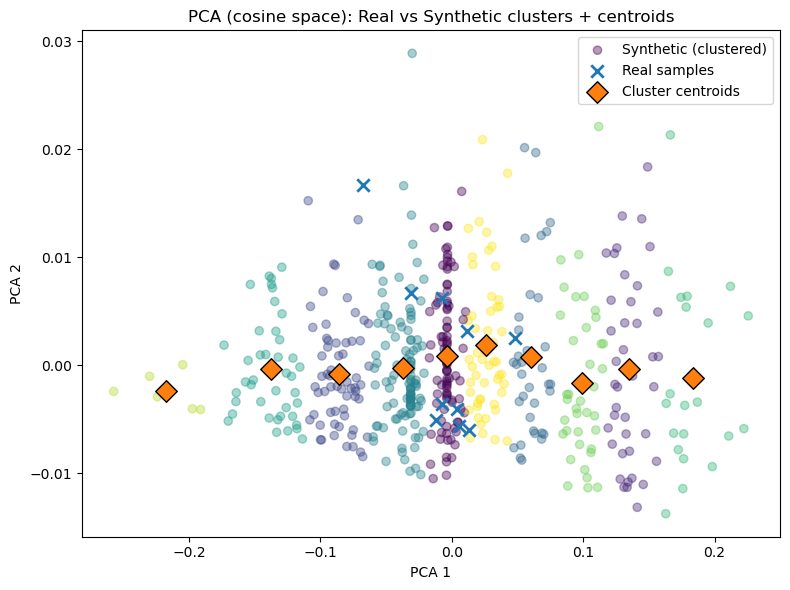

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get original feature matrices ---
num_cols = ["radius_mean", "radius_se", "radius_worst"]

X_real = real_df[num_cols].to_numpy(dtype=float)
X_synth = synth_df[num_cols].to_numpy(dtype=float)

# centroids came from KMeans on S_norm, so they are already in the
# same feature space as row-normalized S. We'll still renormalize
# everything to be safe.

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

# --- 2. Normalize ALL three sets in the same way ---
X_real_norm = normalize_rows(X_real)
X_synth_norm = normalize_rows(X_synth)
centroids_norm = normalize_rows(centroids)   # centroids from KMeans

n_real = X_real_norm.shape[0]
n_synth = X_synth_norm.shape[0]
n_centroids = centroids_norm.shape[0]

# --- 3. Stack and fit PCA on the unified normalized space ---
X_all_norm = np.vstack([X_real_norm, X_synth_norm, centroids_norm])

pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(X_all_norm)

# --- 4. Split back into real / synthetic / centroids ---
X_real_2d = X_all_2d[:n_real]
X_synth_2d = X_all_2d[n_real:n_real + n_synth]
X_centroids_2d = X_all_2d[n_real + n_synth:]

# --- 5. Plot ---
plt.figure(figsize=(8, 6))

# Synthetic (clustered)
plt.scatter(
    X_synth_2d[:, 0],
    X_synth_2d[:, 1],
    c=synth_cluster_labels,
    alpha=0.4,
    marker='o',
    label="Synthetic (clustered)"
)

# Real samples
plt.scatter(
    X_real_2d[:, 0],
    X_real_2d[:, 1],
    marker='x',
    s=80,
    linewidths=2,
    label="Real samples"
)

# Cluster centroids
plt.scatter(
    X_centroids_2d[:, 0],
    X_centroids_2d[:, 1],
    marker='D',
    s=120,
    edgecolors='black',
    label="Cluster centroids"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA (cosine space): Real vs Synthetic clusters + centroids")
plt.legend()
plt.tight_layout()
plt.show()


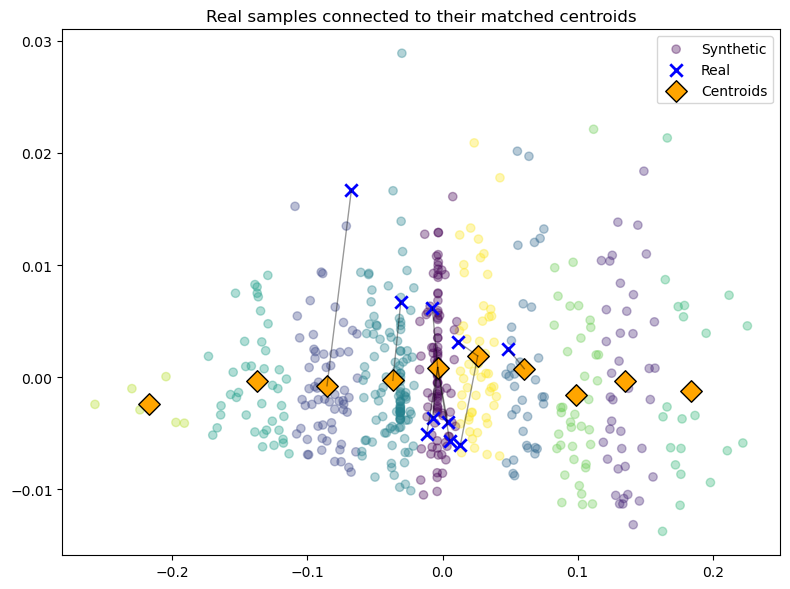

In [32]:
# Lines connecting real samples → their assigned centroid

plt.figure(figsize=(8,6))

# Synthetic points
plt.scatter(
    X_synth_2d[:,0], X_synth_2d[:,1],
    c=synth_cluster_labels, alpha=0.35, label="Synthetic"
)

# Real points
plt.scatter(
    X_real_2d[:,0], X_real_2d[:,1],
    marker='x', s=80, linewidths=2, color='blue',
    label="Real"
)

# Centroids
plt.scatter(
    X_centroids_2d[:,0], X_centroids_2d[:,1],
    marker='D', s=120, edgecolors='black', color='orange',
    label="Centroids"
)

# Draw a line between each real sample and its assigned centroid
for i, c_idx in enumerate(centroid_assignments):
    x1, y1 = X_real_2d[i]
    x2, y2 = X_centroids_2d[c_idx]
    plt.plot([x1, x2], [y1, y2], color='black', alpha=0.4, linewidth=1)

plt.title("Real samples connected to their matched centroids")
plt.legend()
plt.tight_layout()
plt.show()

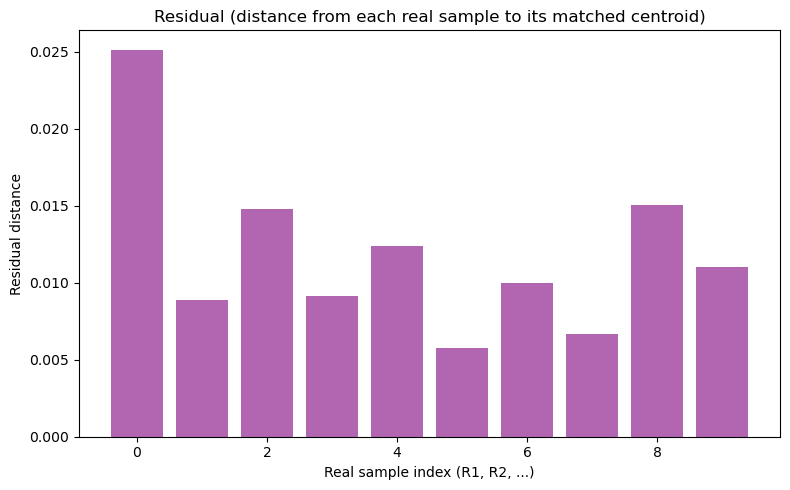

R1 → centroid 2 residual = 0.0251
R2 → centroid 0 residual = 0.0089
R3 → centroid 9 residual = 0.0148
R4 → centroid 4 residual = 0.0091
R5 → centroid 3 residual = 0.0124
R6 → centroid 0 residual = 0.0057
R7 → centroid 0 residual = 0.0100
R8 → centroid 0 residual = 0.0067
R9 → centroid 9 residual = 0.0150
R10 → centroid 0 residual = 0.0110


In [33]:
# Residual Visualization: distance from each real → centroid

# Compute residuals in original normalized space
residuals = np.linalg.norm(X_real_norm - centroids_norm[centroid_assignments], axis=1)

# Bar chart of residuals
plt.figure(figsize=(8,5))
plt.bar(range(len(residuals)), residuals, color='purple', alpha=0.6)
plt.xlabel("Real sample index (R1, R2, ...)")
plt.ylabel("Residual distance")
plt.title("Residual (distance from each real sample to its matched centroid)")
plt.tight_layout()
plt.show()

# Also show numeric output
for i, r in enumerate(residuals):
    print(f"R{i+1} → centroid {centroid_assignments[i]} residual = {r:.4f}")

2D Contour / Density Map of Synthetic Distribution

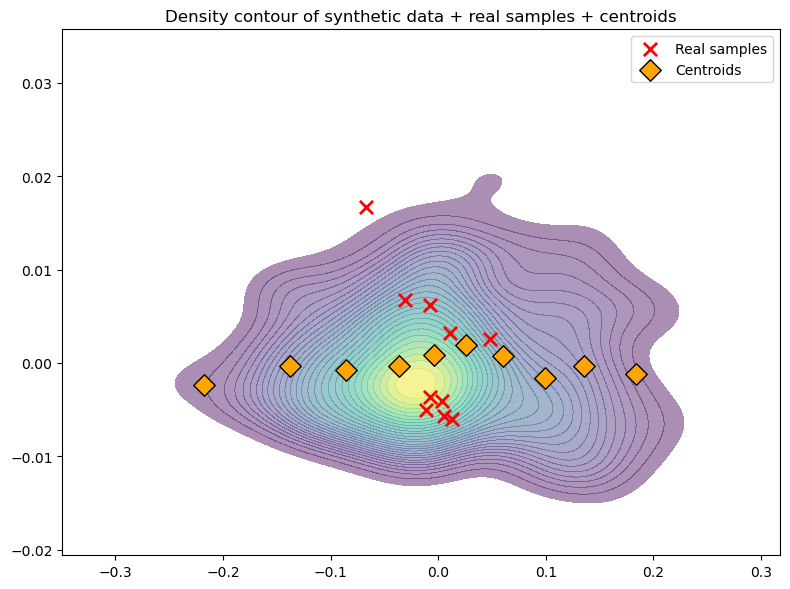

In [37]:
import seaborn as sns

plt.figure(figsize=(8,6))

# Density of synthetic points
sns.kdeplot(
    x=X_synth_2d[:,0],
    y=X_synth_2d[:,1],
    fill=True, cmap="viridis", alpha=0.45, thresh=0.05,
    levels=30
)

# Overlay real points
plt.scatter(
    X_real_2d[:,0], X_real_2d[:,1],
    marker='x', s=90, linewidth=2, color='red',
    label="Real samples"
)

# Overlay centroids
plt.scatter(
    X_centroids_2d[:,0], X_centroids_2d[:,1],
    marker='D', s=120, edgecolors='black', color='orange',
    label="Centroids"
)

plt.title("Density contour of synthetic data + real samples + centroids")
plt.legend()
plt.tight_layout()
plt.show()